In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("D:\capstone-ai-ml\health_insurance_cost_and_risk_dataset.csv")

In [3]:
display(df.head())

,age,sex,bmi,children,smoker,region,charges,blood_pressure,exercise_frequency,pre_existing_condition,occupation_risk,annual_income
0,19.0,female,27.900,0.0,yes,southwest,16884.92400,139.0,Never,True,high,104158.67
1,18.0,male,33.770,1.0,no,southeast,1725.55230,129.9,Weekly,True,moderate,43530.88
2,28.0,male,33.000,3.0,no,southeast,4449.46200,111.1,Rarely,False,high,113004.75
3,33.0,male,22.705,0.0,no,northwest,21984.47061,126.9,Rarely,False,high,185041.26
4,32.0,male,28.880,0.0,no,northwest,3866.85520,134.7,Rarely,True,low,46747.97


In [4]:
print(df.dtypes)

age                       float64
sex                        object
bmi                       float64
children                  float64
smoker                     object
region                     object
charges                   float64
blood_pressure            float64
exercise_frequency         object
pre_existing_condition       bool
occupation_risk            object
annual_income             float64
dtype: object


In [ ]:
print(f"Rows:{df.shape[0]}")
print(f"Columns:{df.shape[1]}")

Rows : 1338
Columns : 12


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     1337 non-null   float64
 1   sex                     1338 non-null   object 
 2   bmi                     1337 non-null   float64
 3   children                1337 non-null   float64
 4   smoker                  1338 non-null   object 
 5   region                  1338 non-null   object 
 6   charges                 1338 non-null   float64
 7   blood_pressure          1338 non-null   float64
 8   exercise_frequency      1338 non-null   object 
 9   pre_existing_condition  1338 non-null   bool   
 10  occupation_risk         1338 non-null   object 
 11  annual_income           1338 non-null   float64
dtypes: bool(1), float64(6), object(5)
memory usage: 116.4+ KB


In [ ]:
mc = df.isnull().sum()

print("Missing values in each column")
print(mc)

Missing Values in Each Column
age                       1
sex                       0
bmi                       1
children                  1
smoker                    0
region                    0
charges                   0
blood_pressure            0
exercise_frequency        0
pre_existing_condition    0
occupation_risk           0
annual_income             0
dtype: int64


In [ ]:
mp = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing count": mc,
    "Missing percentage": mp
})

print("Missing value summary")
display(missing_df)

Missing Value Summary


,Missing Count,Missing Percentage
age,1,0.074738
sex,0,0.000000
bmi,1,0.074738
children,1,0.074738
smoker,0,0.000000
region,0,0.000000
charges,0,0.000000
blood_pressure,0,0.000000
exercise_frequency,0,0.000000
pre_existing_condition,0,0.000000


In [ ]:
hnc = missing_df[
    missing_df["Missing percentage"] > 20
]

if hnc.empty:
    print("No column has more than 20% missing values.")
else:
    print("Columns with more than 20% missing values:")
    display(hnc)

No column has more than 20% missing values.


In [10]:
nc = df.select_dtypes(include=["float64"]).columns

for col in nc:
    null_percent = (df[col].isnull().sum() / len(df)) * 100

    if null_percent < 20:
        median_value = df[col].median()
        df[col].fillna(median_value, inplace=True)

print("filled with median")

filled with median


In [11]:
print(df.isnull().sum())

age                       0
sex                       0
bmi                       0
children                  0
smoker                    0
region                    0
charges                   0
blood_pressure            0
exercise_frequency        0
pre_existing_condition    0
occupation_risk           0
annual_income             0
dtype: int64


In [12]:
dc = df.duplicated().sum()
print(f"Number of duplicate rows:{dc}")

Number of duplicate rows:0


In [13]:

rows_before = len(df)
df = df.drop_duplicates()
rows_after = len(df)
rows_removed = rows_before - rows_after
print(f"Rows before removing duplicates:{rows_before}")
print(f"Rows after removing duplicates:{rows_after}")
print(f"Duplicate rows removed:{rows_removed}")

Rows before removing duplicates:1338
Rows after removing duplicates:1338
Duplicate rows removed:0


In [14]:
mad = (df.isnull().sum() / len(df)) * 100

msa = pd.DataFrame({
    "Missing count": df.isnull().sum(),
    "Missing percentage": mad
})

print("Missing value details after removing duplicates")
display(msa)

Missing value details after removing duplicates


,Missing count,Missing percentage
age,0,0.0
sex,0,0.0
bmi,0,0.0
children,0,0.0
smoker,0,0.0
region,0,0.0
charges,0,0.0
blood_pressure,0,0.0
exercise_frequency,0,0.0
pre_existing_condition,0,0.0


In [ ]:
memory_before = df.memory_usage(deep=True).sum()
print(f"Memory usage before conversion : {memory_before:} bytes")

Memory usage before conversion : 493,455 bytes


In [16]:
df["age"] = df["age"].astype(int)
df["children"] = df["children"].astype(int)
print("age and children column converted to int")

age and children column converted to int


In [17]:
category_cols = [
    "sex",
    "smoker",
    "region",
    "exercise_frequency",
    "occupation_risk"
]

for col in category_cols:
    df[col] = df[col].astype("category")

print("Object columns converted to category")

Object columns converted to category


In [18]:
print(df.dtypes)

age                          int32
sex                       category
bmi                        float64
children                     int32
smoker                    category
region                    category
charges                    float64
blood_pressure             float64
exercise_frequency        category
pre_existing_condition        bool
occupation_risk           category
annual_income              float64
dtype: object


In [ ]:
memory_after = df.memory_usage(deep=True).sum()
print(f"Memory after conversion: {memory_after:} bytes")

Memory after conversion: 73,863 bytes


In [ ]:
memory_after = df.memory_usage(deep=True).sum()

print(f"Memory before : {memory_before:} bytes")
print(f"Memory after  : {memory_after:} bytes")
print(f"Memory saved  : {memory_before - memory_after:} bytes")

Memory before : 493,455 bytes
Memory after  : 73,863 bytes
Memory saved  : 419,592 bytes


In [22]:
print("Descriptive statistics")
display(df.describe())

Descriptive statistics


,age,bmi,children,charges,blood_pressure,annual_income
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.218984,30.664391,1.095665,13270.422265,124.452840,114318.670187
std,14.042963,6.098035,1.205123,12110.011237,8.544297,49654.737363
min,18.000000,15.960000,0.000000,1121.873900,110.100000,30109.230000
25%,27.000000,26.296250,0.000000,4740.287150,117.425000,70928.752500
50%,39.000000,30.400000,1.000000,9382.033000,124.550000,114222.370000
75%,51.000000,34.693750,2.000000,16639.912515,131.400000,157131.387500
max,64.000000,53.130000,5.000000,63770.428010,140.000000,199966.140000


In [ ]:
nc = df.select_dtypes(include=["int32", "int64", "float64"]).columns

skewness = pd.DataFrame({"column": nc,
    "skewness": [df[col].skew() for col in nc]})

display(skewness)

,Column,Skewness
0,age,0.054349
1,bmi,0.283592
2,children,0.937942
3,charges,1.515880
4,blood_pressure,0.074767
5,annual_income,0.039960


In [ ]:
skewness["absolute skewness"] = skewness["skewness"].abs()

most_skewed = skewness.sort_values(by="absolute skewness",ascending=False)

display(most_skewed)
print("\nmost skewed column:")
print(most_skewed.iloc[0])

,Column,Skewness,Absolute Skewness
3,charges,1.515880,1.515880
2,children,0.937942,0.937942
1,bmi,0.283592,0.283592
4,blood_pressure,0.074767,0.074767
0,age,0.054349,0.054349
5,annual_income,0.039960,0.039960



Most Skewed Column:
Column               charges
Skewness             1.51588
Absolute Skewness    1.51588
Name: 3, dtype: object


In [26]:
top_column = most_skewed.iloc[0]["Column"]
top_value = most_skewed.iloc[0]["Skewness"]

print(f"Most skewed column: {top_column}")
print(f"Skewness value: {top_value:.4f}")

if top_value > 0:
    print("The distribution is positively skewed or right-skewed")
    print("Large values pull the mean upward")
else:
    print("The distribution is negatively skewed or left-skewed")
    print("Small values pull the mean downward")

Most skewed column: charges
Skewness value: 1.5159
The distribution is positively skewed or right-skewed
Large values pull the mean upward


In [30]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print("")
    print(f"Column: {column}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Outlier Count: {len(outliers)}")

    return outliers

In [31]:
charges_outliers = detect_outliers_iqr(df,"charges")
bmi_outliers = detect_outliers_iqr(df,"bmi")


Column: charges
Q1: 4740.29
Q3: 16639.91
IQR: 11899.63
Lower Bound: -13109.15
Upper Bound: 34489.35
Outlier Count: 139

Column: bmi
Q1: 26.30
Q3: 34.69
IQR: 8.40
Lower Bound: 13.70
Upper Bound: 47.29
Outlier Count: 9


In [ ]:
summary = pd.DataFrame({"Column": ["charges", "bmi"],"Outlier Count": [len(charges_outliers),len(bmi_outliers)]})
display(summary)

,Column,Outlier Count
0,charges,139
1,bmi,9


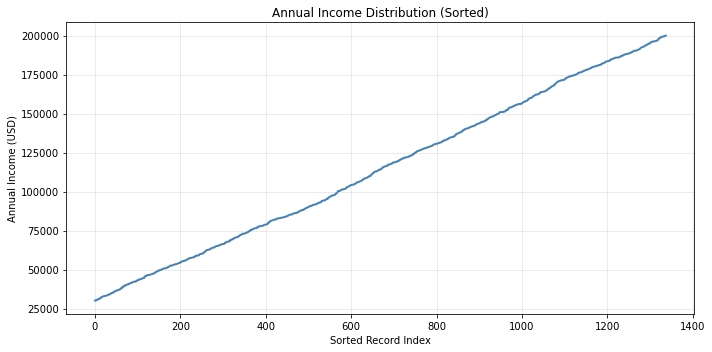

In [ ]:
df_income = df.sort_values("annual_income").reset_index(drop=True)

plt.figure(figsize=(10,5))

plt.plot(df_income.index,df_income["annual_income"],color="steelblue",linewidth=2)

plt.title("Annual Income Distribution (Sorted)")
plt.xlabel("Sorted Record Index")
plt.ylabel("Annual Income (USD)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("visual output/line_plot_annual_income.png", dpi=300)

plt.show()

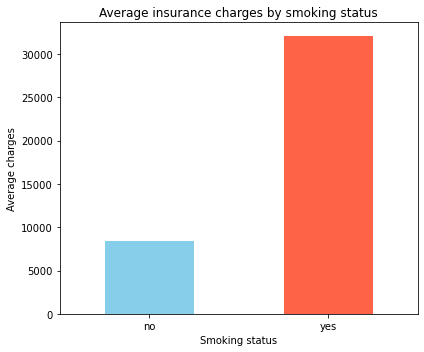

In [ ]:
mean_charges = df.groupby("smoker")["charges"].mean()

plt.figure(figsize=(6,5))

mean_charges.plot(kind="bar", color=["skyblue","tomato"])

plt.title("Average insurance charges by smoking status")
plt.xlabel("Smoking status")
plt.ylabel("Average charges")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("visual output/barchart.png", dpi=300)

plt.show()

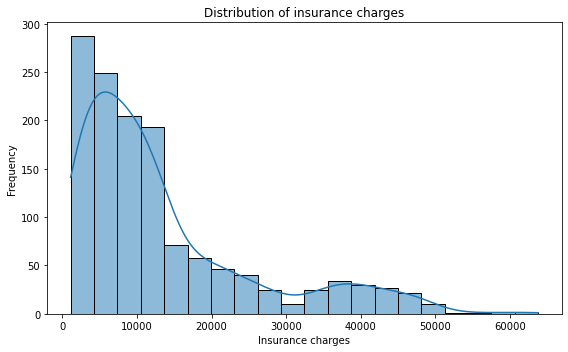

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(df["charges"],bins=20,kde=True)

plt.title("Distribution of insurance charges")
plt.xlabel("Insurance charges")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("visual output/histogram_charges.png", dpi=300)
plt.show()

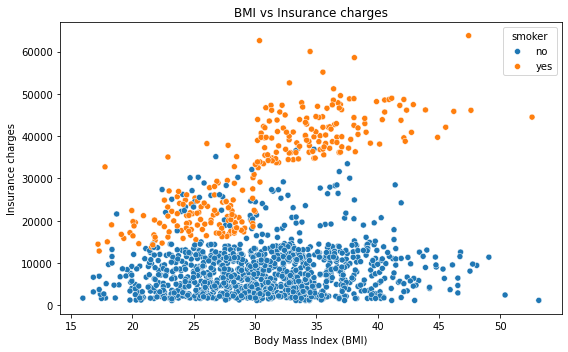

In [39]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker")

plt.title("BMI vs Insurance charges")
plt.xlabel("Body Mass Index (BMI)")
plt.ylabel("Insurance charges")

plt.tight_layout()

plt.savefig("visual output/scatterplot.png", dpi=300)

plt.show()

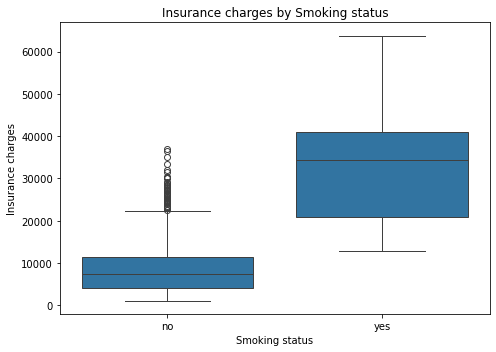

In [40]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df,x="smoker",y="charges")

plt.title("Insurance charges by Smoking status")
plt.xlabel("Smoking status")
plt.ylabel("Insurance charges")

plt.tight_layout()

plt.savefig("visual output/boxplot.png", dpi=300)

plt.show()

In [ ]:
numeric_df = df.select_dtypes(include=["int32", "int64", "float64"])

pearson_corr = numeric_df.corr()

print("Pearson correlation matrix")
display(pearson_corr)

Pearson Correlation Matrix


,age,bmi,children,charges,blood_pressure,annual_income
age,1.000000,0.110104,0.042647,0.298352,-0.081306,-0.003919
bmi,0.110104,1.000000,0.012124,0.198560,-0.050862,0.000228
children,0.042647,0.012124,1.000000,0.068821,0.021867,-0.013881
charges,0.298352,0.198560,0.068821,1.000000,-0.039013,0.002624
blood_pressure,-0.081306,-0.050862,0.021867,-0.039013,1.000000,-0.038975
annual_income,-0.003919,0.000228,-0.013881,0.002624,-0.038975,1.000000


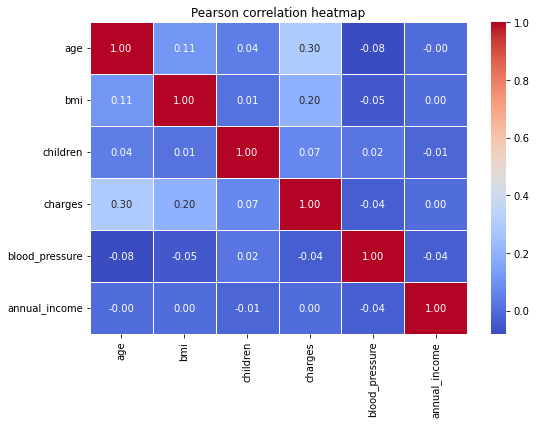

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(pearson_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Pearson correlation heatmap")
plt.tight_layout()
plt.savefig("visual output/correlation_heatmap.png", dpi=300)
plt.show()

In [43]:
corr_abs = pearson_corr.abs()
np.fill_diagonal(corr_abs.values, 0)

max_corr = corr_abs.unstack().idxmax()
max_value = corr_abs.unstack().max()

print("Highest absolute correlation pair")
print(f"Variables: {max_corr[0]} and {max_corr[1]}")
print(f"Correlation: {max_value:.4f}")

Highest absolute correlation pair
Variables: age and charges
Correlation: 0.2984


In [ ]:
top_skewed_cols = ["charges", "children"]

comparison = pd.DataFrame(columns=["Column", "Mean", "Median"])

for col in top_skewed_cols:
    comparison.loc[len(comparison)] = [col,df[col].mean(),df[col].median()]

print("Mean vs Median Comparison")
display(comparison)

Mean vs Median Comparison


,Column,Mean,Median
0,charges,13270.422265,9382.033
1,children,1.095665,1.000


In [46]:
for col in top_skewed_cols:
    df[col] = df[col].fillna(df[col].median())

print("Remaining missing values")
print(df[top_skewed_cols].isnull().sum())

Remaining missing values
charges     0
children    0
dtype: int64


In [47]:
spearman_corr = numeric_df.corr(method="spearman")
print("Spearman Correlation Matrix")
display(spearman_corr)

Spearman Correlation Matrix


,age,bmi,children,charges,blood_pressure,annual_income
age,1.000000,0.108849,0.057351,0.533378,-0.079385,-0.002867
bmi,0.108849,1.000000,0.014534,0.119697,-0.054299,-0.005238
children,0.057351,0.014534,1.000000,0.134595,0.021678,-0.019217
charges,0.533378,0.119697,0.134595,1.000000,-0.060307,-0.025685
blood_pressure,-0.079385,-0.054299,0.021678,-0.060307,1.000000,-0.039957
annual_income,-0.002867,-0.005238,-0.019217,-0.025685,-0.039957,1.000000


In [ ]:
difference = (spearman_corr - pearson_corr).abs()
np.fill_diagonal(difference.values, 0)

difference_pairs = (difference.unstack().reset_index())
difference_pairs.columns = ["Variable 1", "Variable 2","Absolute Difference"]

difference_pairs = difference_pairs[difference_pairs["Variable 1"] < difference_pairs["Variable 2"]]
top3 = difference_pairs.sort_values(by="Absolute Difference",ascending=False).head(3)

print("Top 3 Pearson vs Spearman differences")
display(top3)

Top 3 Pearson vs Spearman differences


,Variable 1,Variable 2,Absolute Difference
3,age,charges,0.235026
9,bmi,charges,0.078863
20,charges,children,0.065773


In [49]:
group_stats = df.groupby("smoker")["charges"].agg(["mean", "std", "count"])
print(group_stats)

                mean           std  count
smoker                                   
no       8434.268298   5993.781819   1064
yes     32050.231832  11541.547176    274


In [ ]:
highest_mean_group = group_stats["mean"].idxmax()
highest_std_group = group_stats["std"].idxmax()

mean_ratio = (group_stats["mean"].max() /group_stats["mean"].min())

print(f"Highest mean group: {highest_mean_group}")
print(f"Highest Std group: {highest_std_group}")
print(f"Mean ratio: {mean_ratio:.2f}")

Highest mean group : yes
Highest Std group : yes
Mean ratio : 3.80


In [51]:
df.to_csv("cleaned_data.csv", index=False)